In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = "/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv"

data = pd.read_csv(file_path , index_col = 'Time')

data

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,,,,,,,,,,,,,,,,,,,,,
0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0


In [4]:
data.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')

We will know the percentege of fraudulent credit card transactions 

In [5]:
print(data['Class'].value_counts())

print("\nPercentage:")
print(data['Class'].value_counts(normalize=True))

Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


<Axes: xlabel='Time', ylabel='Amount'>

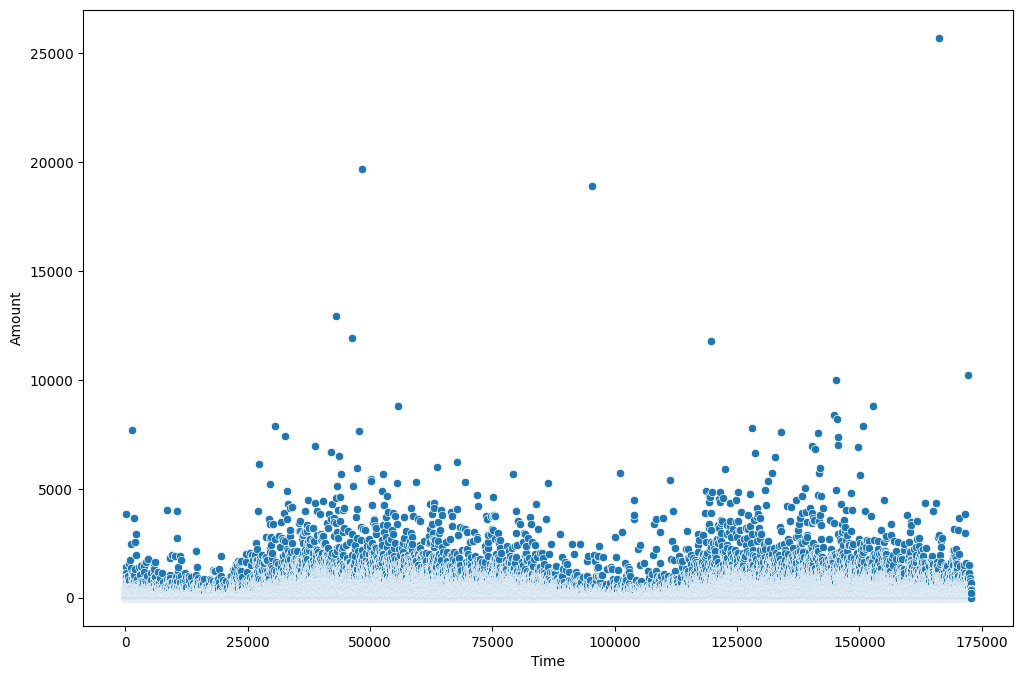

In [6]:
plt.figure(figsize = (12,8))
sns.scatterplot(x = data.index , y = data['Amount'])

The cumulative amount of money transacted throughout the entire period.

<Axes: xlabel='Class', ylabel='Amount'>

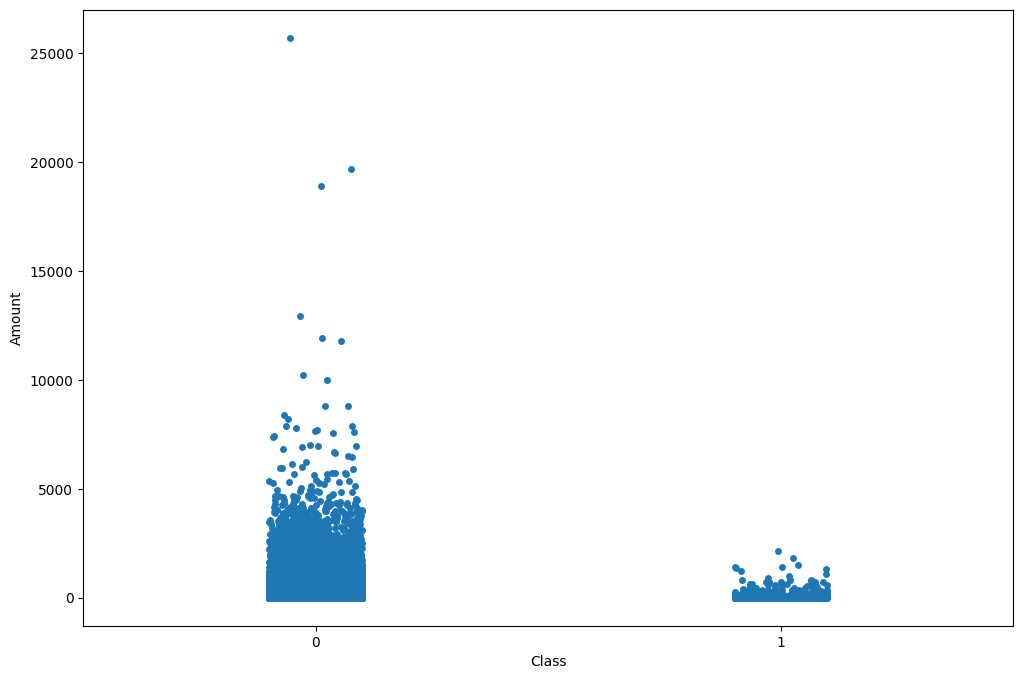

In [7]:
plt.figure(figsize = (12,8))
sns.stripplot(x=data['Class'], y=data['Amount'], jitter=True)

/tmp/ipykernel_17/3724313206.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data = data['Amount'] , shade = True)


<Axes: xlabel='Amount', ylabel='Density'>

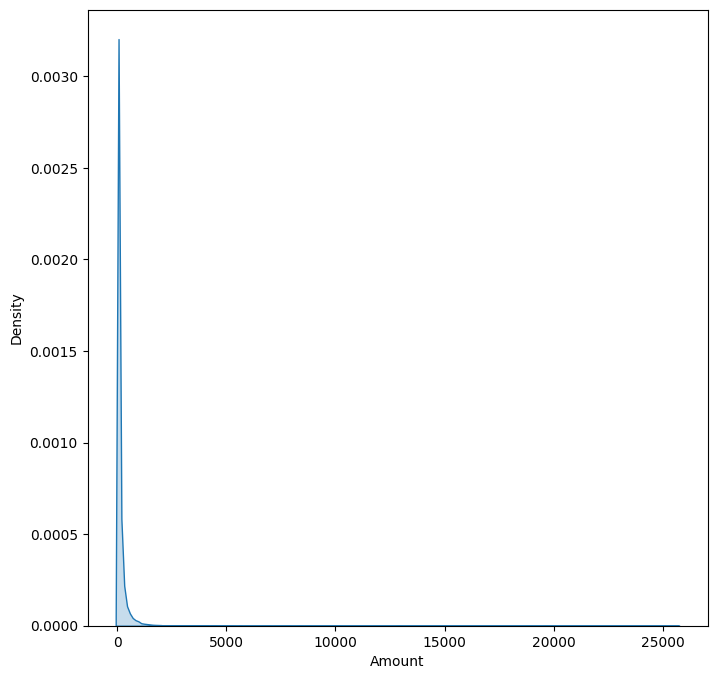

In [8]:
plt.figure(figsize = (8,8))

sns.kdeplot(data = data['Amount'] , shade = True)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler


normal_data = data[data['Class'] == 0]
fraud_data = data[data['Class'] == 1]

X_train, normal = train_test_split(normal_data, test_size=0.25, random_state=0)

X_valid_normal, X_test_normal = train_test_split(normal, test_size=0.5, random_state=0)

X_valid_fruad, X_test_fruad = train_test_split(fraud_data, test_size=0.5, random_state=0)

X_valid = pd.concat([X_valid_normal, X_valid_fruad]).sample(frac=1, random_state=42)
X_test = pd.concat([X_test_normal, X_test_fruad]).sample(frac=1, random_state=42)

X_train_final = X_train.drop(columns=['Class'])

X_valid_final = X_valid.drop(columns=['Class'])
y_valid = X_valid['Class']

X_test_final = X_test.drop(columns=['Class'])
y_test = X_test['Class']

pt = PowerTransformer(method = 'yeo-johnson')

X_train_final_t = pt.fit_transform(X_train_final)

X_valid_final_t = pt.transform(X_valid_final)
X_test_final_t = pt.transform(X_test_final)

X_train_final = pd.DataFrame(X_train_final_t , columns = X_train_final.columns)
X_valid_final = pd.DataFrame(X_valid_final_t , columns = X_valid_final.columns)
X_test_final = pd.DataFrame(X_test_final_t , columns = X_test_final.columns)



In [10]:
X_train_final['Amount'].describe()

count    2.132360e+05
mean    -2.920997e-16
std      1.000002e+00
min     -2.014459e+00
25%     -7.561083e-01
50%      2.822211e-02
75%      7.486128e-01
max      3.671800e+00
Name: Amount, dtype: float64

In [11]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support


epsilons = np.linspace(0.001, 0.1, num=50)

precisions = []
recalls = []
f1_scores = []

for eps in epsilons:

    iso_forest = IsolationForest(contamination=eps, random_state=42, n_jobs=-1)
    iso_forest.fit(X_train_final) 
    
    
    preds = iso_forest.predict(X_valid_final) 
    
    y_pred_converted = np.where(preds == -1, 1, 0)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_valid, y_pred_converted, average='binary', pos_label=1, zero_division=0
    )
    
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_eps = epsilons[best_idx]
best_f1 = f1_scores[best_idx]



In [12]:
import plotly.graph_objects as go    

fig = go.Figure()

# إضافة منحنى الـ Precision
fig.add_trace(go.Scatter(
    x=epsilons, y=precisions, 
    name='Precision', 
    line=dict(color='blue', dash='dash')
))

# إضافة منحنى الـ Recall
fig.add_trace(go.Scatter(
    x=epsilons, y=recalls, 
    name='Recall', 
    line=dict(color='green', dash='dashdot')
))

# إضافة منحنى الـ F1-Score
fig.add_trace(go.Scatter(
    x=epsilons, y=f1_scores, 
    name='F1-Score', 
    line=dict(color='red', width=3)
))

# إضافة خط عمودي عند أفضل إبسيلون
fig.add_vline(
    x=best_eps, 
    line_width=1.5, 
    line_dash="dot", 
    line_color="black",
    annotation_text=f"Best Epsilon ({best_eps:.4f})", 
    annotation_position="top left"
)

# إضافة علامة عند أفضل نقطة F1
fig.add_trace(go.Scatter(
    x=[best_eps], y=[best_f1], 
    mode='markers', 
    marker=dict(color='black', size=10), 
    name='Best Point'
))

# ضبط التنسيق وخاصية تتبع الماوس الموحدة
fig.update_layout(
    title='Evaluating Isolation Forest: Metrics vs Epsilon (Interactive)',
    xaxis_title='Epsilon (Contamination Rate)',
    yaxis_title='Score Value',
    hovermode='x unified',  # السحر كله هنا: بيعمل خط رأسي مع الماوس تلقائياً
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

# عرض الرسمة التفاعلية داخل كاجل
fig.show()

print(f"Best Epsilon is: {best_eps:.4f} F1-Score : {best_f1:.4f}")

Best Epsilon is: 0.0071 F1-Score : 0.4259


In [13]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.0252499, random_state=42, n_jobs=-1)

iso_forest.fit(X_train_final)

raw_predictions = iso_forest.predict(X_valid_final)


y_pred = [1 if x == -1 else 0 for x in raw_predictions]


In [14]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_valid, y_pred))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall  : {recall:.4f} ")
print(f"F1-Score  : {f1:.4f} ")


--- Confusion Matrix ---
[[34695   844]
 [   46   200]]
Accuracy  : 0.9751
Precision  : 0.1916
Recall  : 0.8130 
F1-Score  : 0.3101 


In [15]:
raw_predictions = iso_forest.predict(X_test_final)

y_pred_test = [1 if x == -1 else 0 for x in raw_predictions]

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_test))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall  : {recall:.4f} ")
print(f"F1-Score  : {f1:.4f} ")



--- Confusion Matrix ---
[[34706   834]
 [   64   182]]
Accuracy  : 0.9749
Precision  : 0.1791
Recall  : 0.7398 
F1-Score  : 0.2884 
